# Lab 1 : PAC Learnability, Hypothesis, Regression

---


Total Points: **100**

Tentative Weightage : **6%**

Submission Deadline :  **$10^{th}$ Feburary 2026 , 10:00 AM**

Submit a separate report to mention any observations asked in the corresponding questions. Without these observations, no points will be provided for the corresponding question.
---

**Important Note:**
Question on Logistic Regression will be shared with you by next week as a "part b" of Assignment 1.

General Instructions:

---



1. You have to do this lab individually
2. You may use **seaborn, matplotlib, pandas, numpy, csv**
3. All the code should be submitted in the form of a single Jupyter notebook itself.
4. Points for each sub-section are mentioned in the appropriate question.
5. You can use Google colab to run a jupyter notebook (https://colab.research.google.com/) How to load data in Google Colab ?(https://towardsdatascience.com/3-ways-to-load-csv-files-into-colab-7c14fcbdcb92) (https://www.marktechpost.com/2019/06/07/how-to-connect-google-colab-with-google-drive/). You can also run it in your local anaconda jupyter notebook.
6. The lab must be submitted on Google classroom. The code as well as the accompanying observations (report pdf) should be made part of the assignment.
7. **Code Readability** is very important. Modularize your code by making use of classes, functions that can be flexibly reused wherever necessary. Also use self explanatory variable names and add comments to describe your approach wherever necessary. You may add additional code or text blocks as necessary.
8. You are expected to submit your **observations** (preferably in a separate pdf file) and not just an error free code.
9. Students are expected to follow the **honor code** of the class.
10. The deadline is strict and any assignment submitted later will not
be consider for evaluation unless you take prior permission (at least 4 days before the submission deadline).
11. The marks will be given on the basis of quality of code, use of innovative data structures, scalability, correctness, and completeness of the reported observation.
12. In case of any queries regarding Lab 1, please mail the TAs (emails are provided on the google classroom).

**Best Wishes**


**TASK 1**:                                                      **(10 Marks)**

Create a dataset $\mathcal{D} = (x_i,y_i)_{i=1}^N$ where each $x_i$ is a point in one dimension and each $y_i$ is a binary label i.e. $y_i = \{0,1\}$. First generate the vector $Y$ where each example will take $y_i = 1$ with probability $1/2$ and $y_i = 0$ with probability $1/2$ with $N = 30$. Now fixing the $y_i$, sample the $X$ matrix as follows:


1. If $y_i = 1$ then $x_i \sim \mathcal{N}(3,1)$ where $\mathcal{N}(a,b)$ represent the gaussian distribution with mean $a$ and standard deviation $b$.
    
2. If $y_i = 0$ then $x_i \sim \mathcal{N}(4.5,1)$.
   
  
Implement the following with respect to the above generated dataset:

1. Color code the examples with $y_i = 1$ as red and $y_i=0$ as green and plot the dataset.  **[1 Marks]**
2. Find a threshold hypothesis $\theta$ that minimizes empirical risk. Plot the obtained hypothesis along with the dataset.  **[3 Marks]**
3. What is the optimal threshold hypothesis $\theta^*$ here and provide the generalization error corresponding the same. **[3 Marks]**
4. Plot the empirical error and generalization error for obtained different hypothesis $\theta$s against different value of $N$. Mention what minimum value of $N$ is required to reach $\epsilon$ close to $\theta^*$.  **[3 Marks]**


Write your code by creating cells below.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(42)

def generate_dataset(n):
  # x is the the 1-d feature vector
  # y is the label vector, which is discrete 0 or 1
  y = np.random.binomial(1,0.5,n)
  x = np.zeros(n)
  for i in range(n):
    if(y[i] == 1):
      x[i] = np.random.normal(3,1)
    else:
      x[i] = np.random.normal(4.5,1)
  return x,y

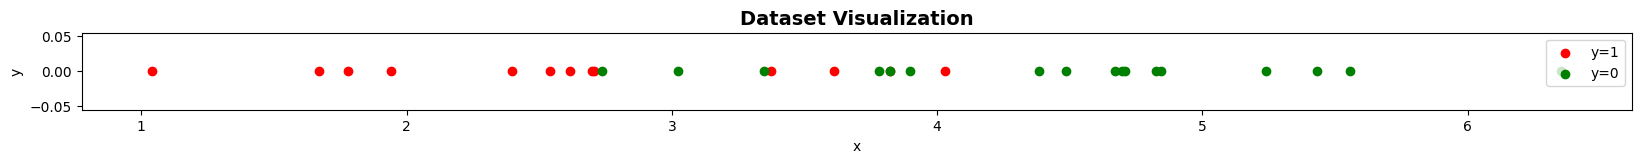

In [52]:
# Task 1.1
n = 30
X,Y = generate_dataset(n)

plt.figure(figsize = (20,1))
# 3 rows, 1 column, activating the 1st box

X_label1 = []
X_label0 = []
for i in range(n):
  if(Y[i]==1):
    X_label1.append(X[i])
  else:
    X_label0.append(X[i])

plt.scatter(X_label1, [0]*len(X_label1), c='red', label='y=1')
plt.scatter(X_label0, [0]*len(X_label0), c='green', label='y=0')
plt.xlabel('x')
plt.ylabel('y')

plt.title('Dataset Visualization', fontsize=14, fontweight='bold')
plt.legend()

Optimal threshold θ^: 2.7226330474219944
Empirical error:  0.13333333333333333


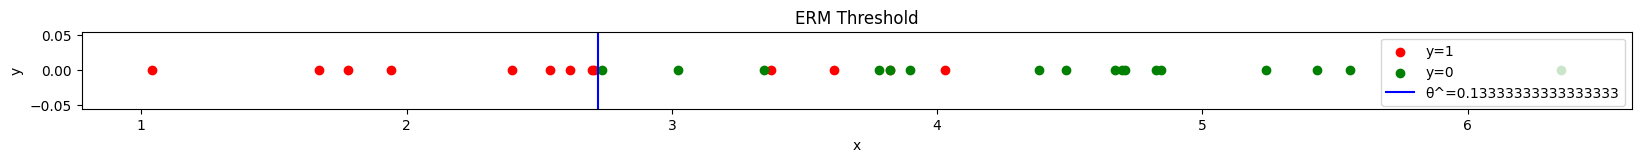

In [53]:
# Task 1.2
def empirical_error(X,Y,n,theta):
  # let the hypothesis h(x) be 1 if x < theta and h(x) = 0 otherwise
  errors = 0
  for i in range(n):
    if(X[i] < theta and Y[i] != 1):
      # False Negative
      errors += 1
    elif(X[i] >= theta and Y[i] != 0):
      # False Positive
      errors += 1
  return errors/n

def erm_hypothesis(X,Y,n):
  X_sorted = np.sort(X)
  # dhc is discrete hypothesis class
  dhc = []
  for i in range(n-1):
    dhc.append((X_sorted[i]+X_sorted[i+1])/2)
  empirical_errors = [empirical_error(X,Y,n,theta) for theta in dhc]
  erm = dhc[np.argmin(empirical_errors)]
  erm_value = min(empirical_errors)
  return erm,erm_value

erm,erm_value = erm_hypothesis(X,Y,n)
print("Optimal threshold θ^:", erm)
print("Empirical error: ", erm_value)

plt.figure(figsize = (20,1))
plt.scatter(X_label1, [0]*len(X_label1), c='red', label='y=1')
plt.scatter(X_label0, [0]*len(X_label0), c='green', label='y=0')
plt.axvline(erm, color='blue', label=f'θ^={erm_value}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('ERM Threshold')
plt.legend()

In [54]:
# Task 1.3
# using bayes optimal predictor
def phi(x):
    return 0.5 * (1 + math.erf(x/ math.sqrt(2)))

def generalization_error(theta):
  # P(error) = P(y=1)*P(x>=theta | y=1) + P(y=0)*P(x<theta | y=0)
    p_one = 0.5
    p_zero = 0.5
    return p_one*(1-phi(theta-3)) + p_zero*(phi(theta-4.5))

from scipy import stats
def generalization_error_scipy(theta):
  # used direct functions from scipy instead of calculating cdf
  p_one = p_zero = 0.5
  # P(x>=theta | y=1)
  return p_one*(1 - stats.norm.cdf(theta, loc=3, scale = 1)) + p_zero* (stats.norm.cdf(theta, loc=4.5 , scale = 1))

# Find theoretical optimal threshold
theta_star = (3+4.5)/2
print("theta_star: ", theta_star)
print("generalization error: ", generalization_error(theta_star))


theta_star:  3.75
generalization error:  0.22662735237686824


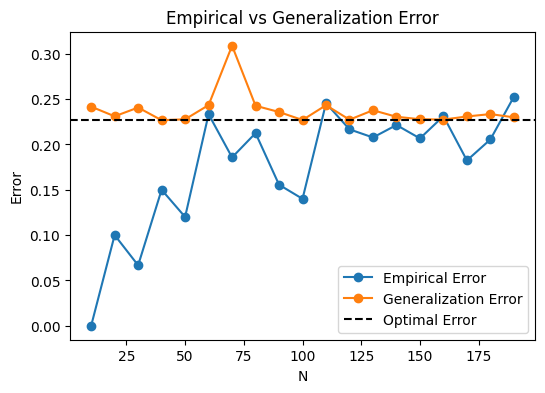

In [55]:
# Task 1.4
N = [10*i for i in range(1,20)]
ee = []
ge = []
for n in N:
  X,Y = generate_dataset(n)
  erm , erm_value = erm_hypothesis(X,Y,n)
  ee.append(erm_value)
  ge.append(generalization_error(erm))

plt.figure(figsize=(6,4))
plt.plot(N, ee, marker = 'o',label='Empirical Error')
plt.plot(N, ge,marker = 'o',label='Generalization Error')
plt.axhline(generalization_error(theta_star), color='black', linestyle='--', label='Optimal Error')

plt.xlabel("N")
plt.ylabel("Error")
plt.title("Empirical vs Generalization Error")
plt.legend()
plt.show()


**TASK 2**:                                                      **(50 Marks)**


Generate $n=30$ data points from function $f(x) = e^{(\pi x/8)} + \frac{x}{12\pi} + \text{noise}$ where noise$\sim \mathcal{N}(0,0.004)$ with $x$ ranging from $0$ to $10$.  **[3 Marks]**

1. Fit a polynomial regression with optimal weight vector $w^*$ computed via analytical method (using idea of matrices) and plot the curves for different degree of polynomials $M=2,4,5,7,10$. Explain your observations by plotting the data points generated and the curve obtained for different values of $M$.  **[3 Marks]**

2. Fit a polynomial regression using gradient descent for different degree of polynomials $M=2,4,5,7,10$. Explain your observations by plotting the data points generated and the curve obtained for different values of $M$.  **[5 Marks]**

      For Stochastic Gradient Descent refer: https://www.mit.edu/~gfarina/2024/67220s24_L10_sgd/L10.pdf


3. Repeat the previous experiments with more number of data points and report your findings. More specifically, compare the above two approaches with respect to the solution obtained with respect to each value of M. **[5 Marks]**

4. Plot runtime of both methods against variation with respect to $M$.
 **[3 Marks]**

5. Plot runtime of both methods against variation with respect to number of datapoints.  **[3 Marks]**

6. Fix the number of training samples to $n = 30$.
- For polynomial degrees $M \in \{5, 10, 15\}$, train polynomial regression models using $\ell_2$ regularization (ridge) and $\ell_1$ regularization (lasso).


  **For a polynomial hypothesis:**
$$
h_w(x) = \sum_{j=0}^M w_j x^j,
$$

           the ridge regression objective is
$$
\min_w \; \frac{1}{n}\sum_{i=1}^n \big(h_w(x_i) - y_i\big)^2
+ \lambda \sum_{j=1}^M w_j^2,
$$

            and the lasso regression objective is
$$
\min_w \; \frac{1}{n}\sum_{i=1}^n \big(h_w(x_i) - y_i\big)^2
+ \lambda \sum_{j=1}^M |w_j|.
$$
  Vary the regularization strength (i.e. regularization parameter $\lambda\in \{0.1,0.05,.01,.05,.001\}$) and plot the training and test MSE for each $M$.

  Fix the polynomial degree to $M = 10$.
- Vary the number of training samples $n \in \{20, 50, 100, 200\}$.
For each $n$, evaluate different regularization strengths and plot the test MSE as a function of the regularization parameter.**[10 Marks]**

7. Sample Complexity for Fixed Error
- Target test MSE $<0.05$
- For each $M=1,3,9$, find min $n$ over **20 runs** s.t. holds w.p. $>0.9$
- Relate to VC-dim $\approx M+1$: **plot** required $n$ vs. $M$. **[8 Marks]**


8. Non-Realizable Noise Comparison
- Add Poisson noise ($\lambda=0.1 |f(x)|$)
- With **20 runs**, $n=30$, $M=1$ to 15, plot mean/std train/test MSE vs. $M$
- Identify the best and worst $M$ for which the hypothesis underfit and overfit
- Discuss convergence to $\min R(h)$, where $R(h)$ denotes the true (population) risk of a hypothesis $h$ under squared loss. **[10 Marks]**

**Use of sci-kit or any direct implementation of linear regression is striclty probhibted. You can use numpy and pandas.**
Write your code by creating cells below.


In [2]:
# Task 2.0
np.random.seed(42)

def function(x):
  return np.exp((np.pi*x)/8) + x/(12*np.pi)

def generate_dataset(n=30, noise=0.004):
  x = np.linspace(0,10,n)
  f = function(x)
  noise = np.random.normal(0,np.sqrt(0.004),size=n)
  y = f+noise
  return x,y

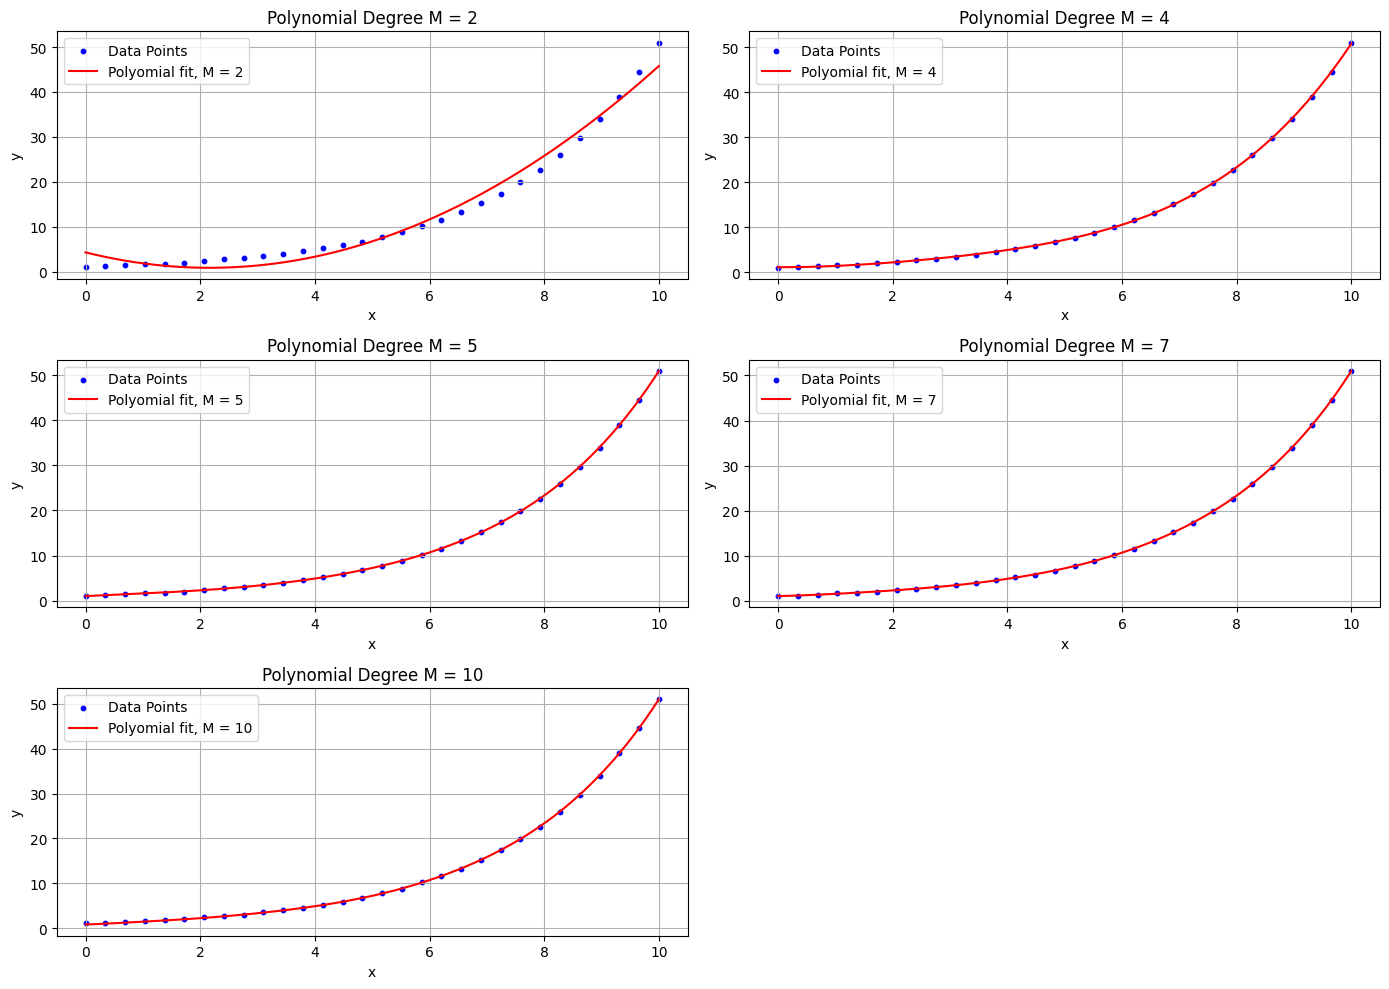

In [3]:
# Task 2.1
x,y = generate_dataset()
def polynomial_features(x,M):
  return np.vstack([x**j for j in range(M+1)]).T

def polynomial_regression(x,y,M):
  phi = polynomial_features(x,M)
  w = np.linalg.inv(phi.T @ phi) @ phi.T @ y
  return w

def predict(x,w):
  M = len(w)-1
  phi = polynomial_features(x,M)
  return phi@w

degrees = [2,4,5,7,10]
x_test = np.linspace(0,10,400)
plt.figure(figsize = (14,10))
for i,M in enumerate(degrees,1):
  y_pred = predict(x_test,polynomial_regression(x,y,M))
  plt.subplot(3,2,i)
  plt.scatter(x,y,color='blue',label='Data Points', s=10)
  plt.plot(x_test, y_pred, color='red', label=f'Polyomial fit, M = {M}')
  plt.xlabel('x')
  plt.ylabel('y')
  plt.title(f'Polynomial Degree M = {M}')
  plt.legend()
  plt.grid(True)

plt.tight_layout()
plt.show()

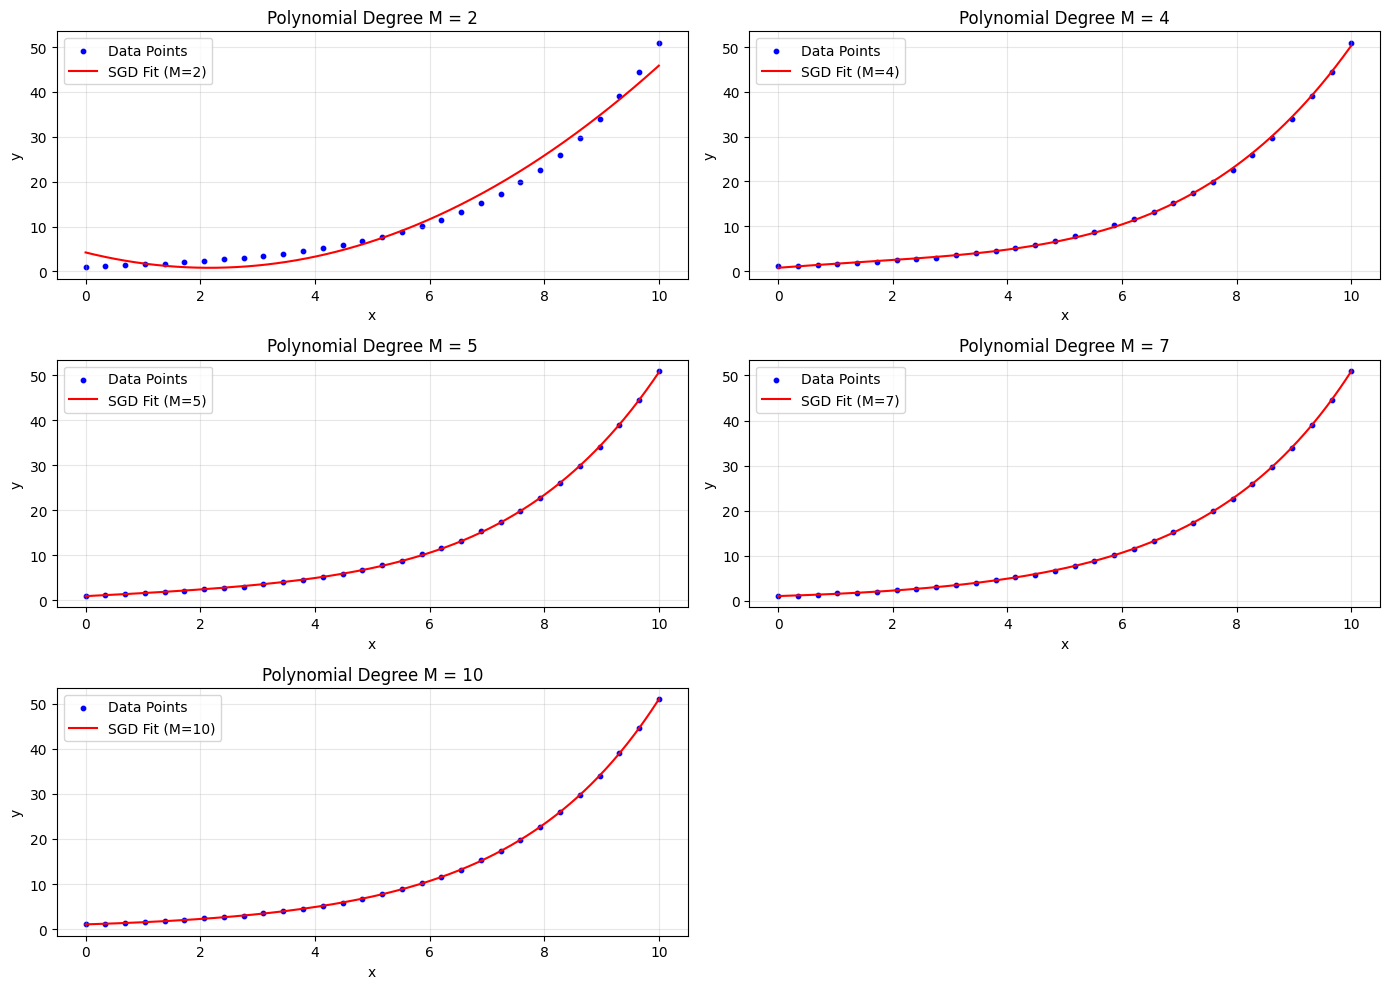

In [4]:
def standardize(phi):
    mu = np.mean(phi, axis=0)
    sigma = np.std(phi, axis=0)
    sigma[0] = 1
    mu[0] = 0
    phi_std = (phi - mu) / sigma
    return phi_std, mu, sigma

def polynomial_regression_sgd(x, y, M, lr, epochs):
    phi = polynomial_features(x, M)
    phi_scaled, mu, sigma = standardize(phi)
    n, d = phi_scaled.shape
    w = np.zeros(d)

    for epoch in range(epochs):
        indices = np.random.permutation(n)
        for i in indices:
            xi = phi_scaled[i]
            yi = y[i]
            pred = np.dot(xi, w)
            error = pred-yi
            gradient = error*xi
            w -= lr*gradient
    return w, mu, sigma

def predict_scaled(x_new, w, M, mu, sigma):
    phi_new = polynomial_features(x_new,M)
    phi_new_scaled = (phi_new-mu)/sigma
    return phi_new_scaled @ w

plt.figure(figsize=(14, 10))

for i, M in enumerate(degrees, 1):
    lr = 0.01
    epochs = 2000
    w_star, mu, sigma = polynomial_regression_sgd(x, y, M, lr=lr, epochs=epochs)
    y_pred = predict_scaled(x_test, w_star, M, mu, sigma)
    plt.subplot(3, 2, i)
    plt.scatter(x, y, color='blue', label='Data Points', s=10)
    plt.plot(x_test, y_pred, color='red', label=f'SGD Fit (M={M})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Polynomial Degree M = {M}')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

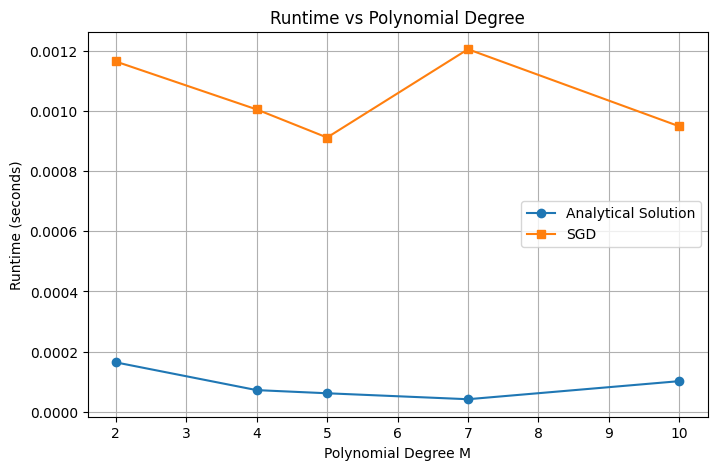

In [5]:
# Task 2.4
import time
degrees = [2,4,5,7,10]
runtime_analytical = []
runtime_sgd = []

for m in degrees:
  start = time.time()
  _ = polynomial_regression(x,y,m)
  runtime_analytical.append(time.time()-start)

  start = time.time()
  _ = polynomial_regression_sgd(x, y, m, lr=0.01, epochs = 10)
  runtime_sgd.append(time.time()-start)

plt.figure(figsize = (8,5))
plt.plot(degrees, runtime_analytical, marker='o', label='Analytical Solution')
plt.plot(degrees, runtime_sgd, marker='s', label='SGD')
plt.xlabel('Polynomial Degree M')
plt.ylabel('Runtime (seconds)')
plt.title('Runtime vs Polynomial Degree')
plt.legend()
plt.grid(True)
plt.show()

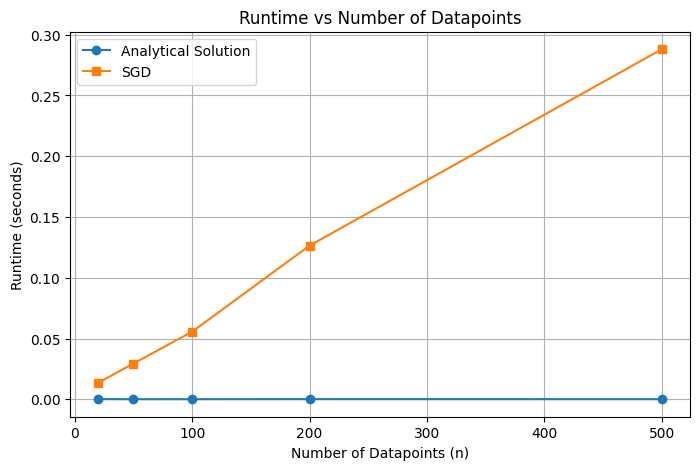

In [6]:
# Task 2.5
data_sizes = [20, 50, 100, 200, 500]
runtime_analytical_n = []
runtime_sgd_n = []

M = 5

for n in data_sizes:
    x_n, y_n = generate_dataset(n)

    # Analytical timing
    start = time.time()
    _ = polynomial_regression(x_n, y_n, M)
    runtime_analytical_n.append(time.time() - start)

    # SGD timing
    start = time.time()
    _ = polynomial_regression_sgd(x_n, y_n, M, lr=0.01, epochs=200)
    runtime_sgd_n.append(time.time() - start)

# Plot
plt.figure(figsize=(8,5))
plt.plot(data_sizes, runtime_analytical_n, marker='o', label='Analytical Solution')
plt.plot(data_sizes, runtime_sgd_n, marker='s', label='SGD')
plt.xlabel('Number of Datapoints (n)')
plt.ylabel('Runtime (seconds)')
plt.title('Runtime vs Number of Datapoints')
plt.legend()
plt.grid(True)
plt.show()


In [7]:
# Task 2.6
def mse(y_true, y_pred):
  sm = 0
  for i in range(len(y_true)):
    sm += (y_true[i]-y_pred[i])**2
  return sm/(len(y_true))

def ridge(x, y, M, lambd):
  phi = polynomial_features(x, M)
  phi_scaled, mu, sigma = standardize(phi)
  n,d = phi_scaled.shape
  I = np.eye(d)
  I[0,0] = 0

  mata = phi_scaled.T @ phi_scaled + (n* lambd * I)
  w = np.linalg.inv(mata) @ (phi_scaled.T @ y)

  return w, mu, sigma

def lasso(x, y, M, lambd, lr=0.01, epochs = 5000):
  phi = polynomial_features(x, M)
  phi_scaled, mu, sigma = standardize(phi)
  n,d = phi_scaled.shape
  w = np.zeros(d)
  for epoch in range(epochs):
    y_pred = phi_scaled @ w
    error = y_pred - y
    gradient_mse = (2/n) * (phi_scaled.T @ error)
    gradient_reg = lambd * np.sign(w)
    gradient_reg[0] = 0

    total_gradient = gradient_mse + gradient_reg
    w -= (lr/(1 + 0.001 * epoch)) * total_gradient
  return w,mu,sigma

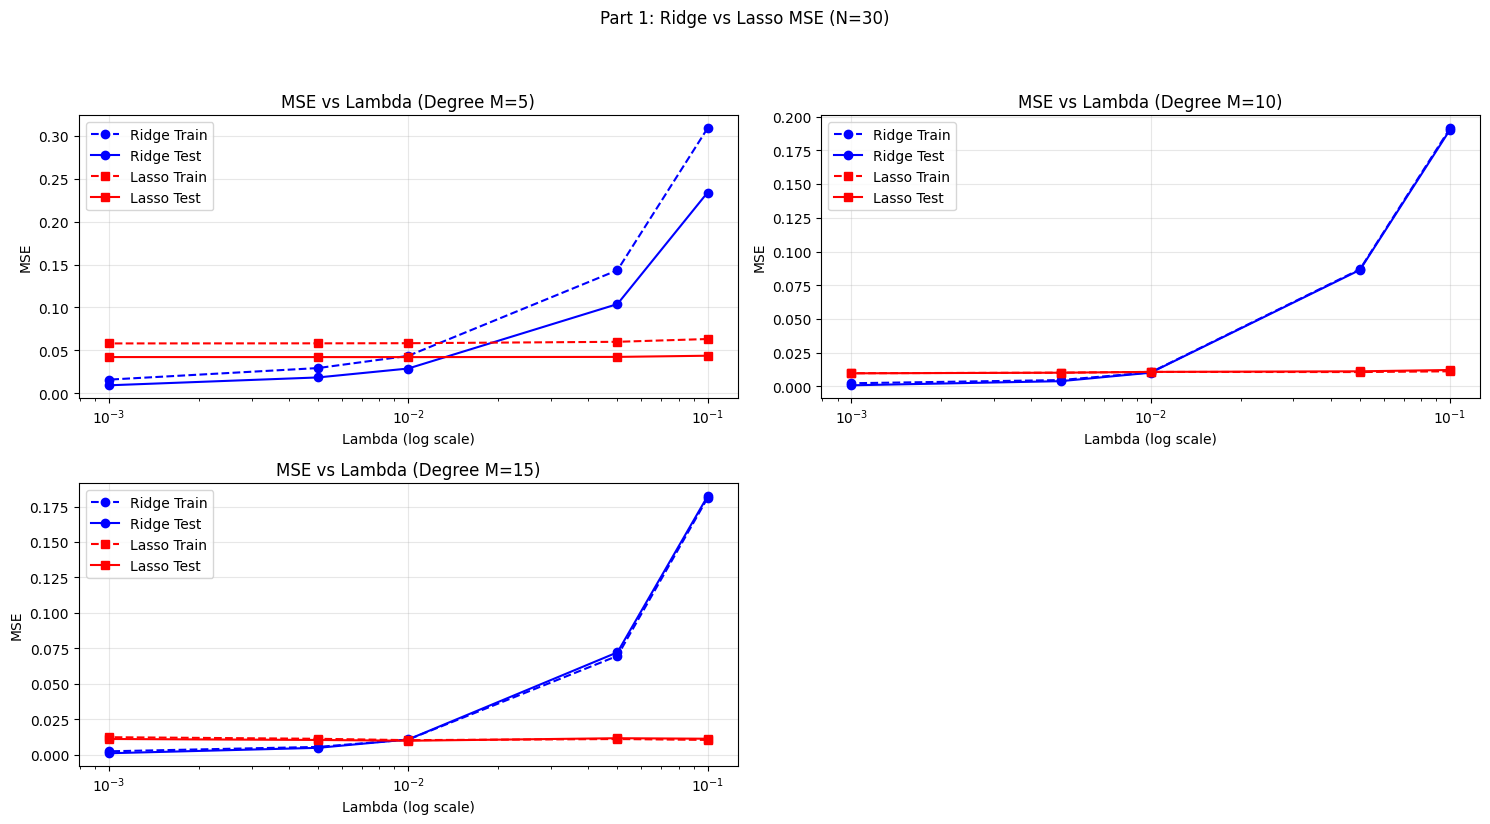

In [8]:
# Task 2.6 plots
n = 30
deg = [5, 10 ,15]
lambdas = [0.1, 0.05, 0.01, 0.005, 0.001]
lambdas.sort(reverse = True)

x_train, y_train = generate_dataset(n)
x_test = np.linspace(0, 10, 200)
y_test = function(x_test)

plt.figure(figsize = (15, 12))
plt.suptitle(f"Part 1: Ridge vs Lasso MSE (N={n})")
index = 1
for m in deg:
  ridge_train = []
  ridge_test = []
  lasso_train = []
  lasso_test = []

  for lam in lambdas:
    wr, mur, sigr = ridge(x_train, y_train, m, lam)
    ridge_train.append(mse(y_train, predict_scaled(x_train, wr, m, mur, sigr)))
    ridge_test.append(mse(y_test, predict_scaled(x_test, wr, m, mur, sigr)))

    wl, mul, sigl = lasso(x_train, y_train, m, lam)
    lasso_train.append(mse(y_train, predict_scaled(x_train, wl, m, mul, sigl)))
    lasso_test.append(mse(y_test, predict_scaled(x_test, wl, m, mul, sigl)))

  plt.subplot(3, 2, index)
  plt.plot(lambdas, ridge_train, 'b--o', label='Ridge Train')
  plt.plot(lambdas, ridge_test, 'b-o', label='Ridge Test')
  plt.plot(lambdas, lasso_train, 'r--s', label='Lasso Train')
  plt.plot(lambdas, lasso_test, 'r-s', label='Lasso Test')
  plt.xscale('log')
  plt.title(f'MSE vs Lambda (Degree M={m})')
  plt.xlabel('Lambda (log scale)')
  plt.ylabel('MSE')
  plt.legend()
  plt.grid(True, alpha=0.3)
  index += 1

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

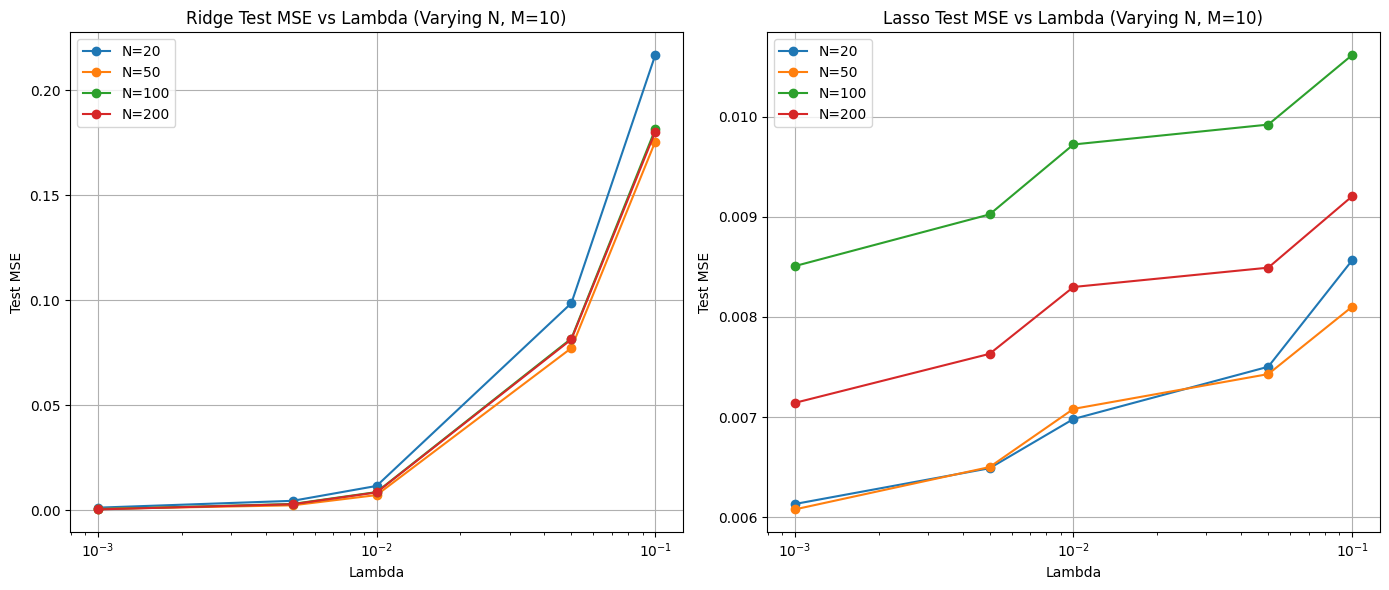

In [9]:
# Task 2.6 plots
N = [20, 50, 100, 200]
m = 10
lambdas = [0.1, 0.05, 0.01, 0.005, 0.001]

plt.figure(figsize = (14,6))

plt.subplot(1,2,1)
plt.title(f"Ridge Test MSE vs Lambda (Varying N, M={m})")
for n in N:
  X,y = generate_dataset(n)
  err = []
  for lam in lambdas:
    wr, mur, sigr = ridge(X,y,m,lam)
    err.append(mse(y_test, predict_scaled(x_test, wr, m, mur, sigr)))
  plt.plot(lambdas, err, marker = 'o', label = f'N={n}')
  plt.xscale('log')
  plt.xlabel('Lambda')
  plt.ylabel('Test MSE')
  plt.legend()
  plt.grid(True)

plt.subplot(1,2,2)
plt.title(f"Lasso Test MSE vs Lambda (Varying N, M={m})")
for n in N:
  X,y = generate_dataset(n)
  err = []
  for lam in lambdas:
    wl, mul, sigl = lasso(X,y,m,lam)
    err.append(mse(y_test, predict_scaled(x_test, wl, m, mul, sigl)))
  plt.plot(lambdas, err, marker = 'o', label = f'N={n}')
  plt.xscale('log')
  plt.xlabel('Lambda')
  plt.ylabel('Test MSE')
  plt.legend()
  plt.grid(True)

plt.tight_layout()
plt.show()

  M=[1, 3, 9]: No n < 200 satisfies condition
  M=[1, 3, 9]: No n < 200 satisfies condition
  M=[1, 3, 9]: min n = 11 (20/20 successes)


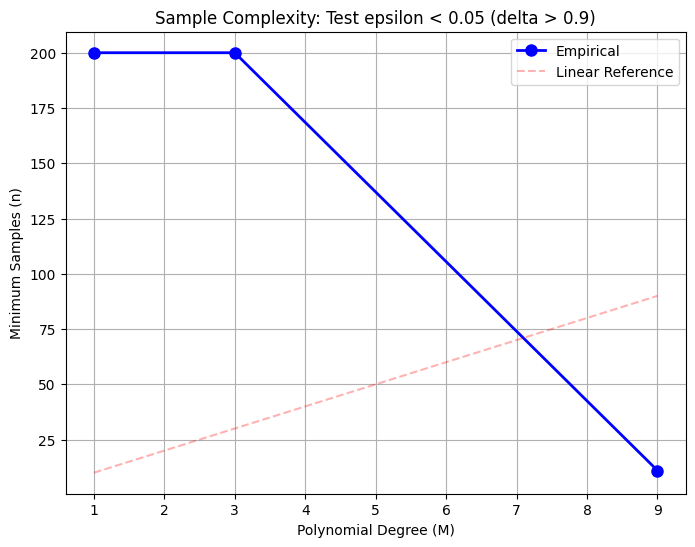

In [10]:
# Task 2.7
M=[1, 3, 9]
eps = 0.05
delta = 0.90
t = 20
minn = []

nspace = range(5, 200, 2)

for m in M:
    flag = False
    for n in nspace:
        if(n <= m+1):
            continue
        ok = 0
        for _ in range(t):
            X, y = generate_dataset(n)
            w, mu, sig = ridge(X,y,m,1e-8)
            err = mse(y_test, predict_scaled(x_test, w, m, mu, sig))
            if (err < eps):
                ok += 1

        if ok / t >= delta:
            minn.append(n)
            print(f"  M={M}: min n = {n} ({ok}/{t} successes)")
            flag = True
            break

    if not flag:
        print(f"  M={M}: No n < 200 satisfies condition")
        minn.append(200)

plt.figure(figsize=(8, 6))
plt.plot(M, minn, 'bo-', lw=2, ms=8)
plt.plot(M, [10*m for m in M], 'r--', alpha=0.3)

plt.xlabel("Polynomial Degree (M)")
plt.ylabel("Minimum Samples (n)")
plt.title("Sample Complexity: Test epsilon < 0.05 (delta > 0.9)")
plt.legend(["Empirical", "Linear Reference"])
plt.grid(True)
plt.show()


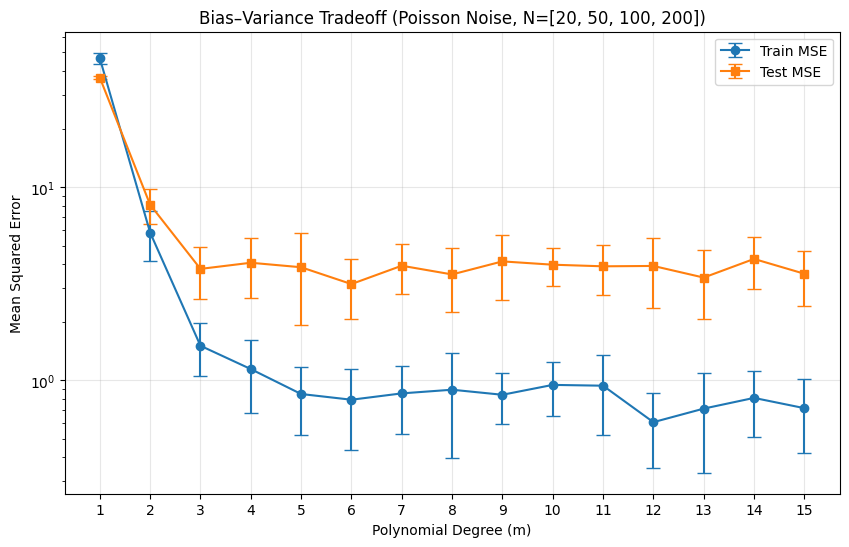

1. Best Model       : M = 6
2. Worst Underfit   : M = 1
3. Worst Overfit    : M = 1


In [11]:
# Task 2.8
def poisson(n):
    x = np.linspace(0, 10, n)
    f = function(x)
    lam = 0.1 * np.abs(f)
    noise = np.random.poisson(lam)
    y = f + noise
    return x, y

n = 30
M = range(1, 16)
t = 20

trm, trs = [], []
tem, tes = [], []

for m in M:
    trerr, teerr = [], []

    for _ in range(t):
        X, y = poisson(n)
        w, mu, sig = ridge(X, y, m, 1e-8)
        trerr.append(mse(y, predict_scaled(X, w, m, mu, sig)))
        teerr.append(mse(y_test, predict_scaled(x_test, w, m, mu, sig)))

    trm.append(np.mean(trerr))
    trs.append(np.std(trerr))
    tem.append(np.mean(teerr))
    tes.append(np.std(teerr))

trm = np.array(trm)
trs  = np.array(trs)
tem = np.array(tem)
tes  = np.array(tes)

plt.figure(figsize=(10, 6))
plt.errorbar(M, trm, yerr=trs, fmt='-o', capsize=5, label="Train MSE")
plt.errorbar(M, tem, yerr=tes, fmt='-s', capsize=5, label="Test MSE")

plt.xlabel("Polynomial Degree (m)")
plt.ylabel("Mean Squared Error")
plt.title(f"Bias–Variance Tradeoff (Poisson Noise, N={N})")
plt.xticks(M)
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

bestm = M[np.argmin(tem)]
under = 1
over = M[np.argmax(tem)]

print(f"1. Best Model       : M = {bestm}")
print(f"2. Worst Underfit   : M = {under}")
print(f"3. Worst Overfit    : M = {over}")

**TASK 3**:                                                      **(50 Marks)**

Consider the hypothesis class  
$$
\mathcal{H} = \{ h_{a,b} : [0,1]^2 \rightarrow \{0,1\} \mid h_{a,b}(x_1,x_2) = \mathbf{1}[x_1 \le a \ \text{and}\ x_2 \ge b],\ a,b \in [0,1] \}.
$$

Points are sampled i.i.d. from the uniform distribution over $[0,1]^2$.  
The true labeling function is realizable and given by  
$$
h^* = h_{0.3,\,0.7}.
$$



---

Subtask 3a: Dataset Generation and ERM Finder:

- Generate $n$ i.i.d. samples $(X_i, y_i)$, where  
  $X_i \sim \text{Uniform}([0,1]^2)$ and $y_i = h^*(X_i)$.
- Implement an ERM (Empirical Risk Minimization) procedure that finds parameters $(\hat{a}, \hat{b})$ minimizing the empirical risk
  $$
  \hat{R}(h_{a,b}) = \frac{1}{n}\sum_{i=1}^n \mathbf{1}[h_{a,b}(X_i) \neq y_i].
  $$
- Restrict the search to candidate thresholds induced by the data:  
  $a$ values from observed $x$-coordinates and $b$ values from observed $y$-coordinates. **[10 Marks]**

**Expected Output:**  
Estimated values $\hat{a}$, $\hat{b}$, and the corresponding empirical error.

---

Subtask 3b: Error Convergence with Number of Samples:

- Treat the hypothesis class as finite due to data-dependent boundaries $(|\mathcal{H}| \le n^2)$.
- For sample sizes  
  $n \in \{10, 20, 50, 100, 200, 500, 1000\}$,  
  repeat the experiment 20 times.
- For each run, compute:
  - Empirical risk of the ERM hypothesis
  - True risk with respect to the uniform distribution over $[0,1]^2$

- Report the mean and standard deviation of both errors across runs.
- Plot empirical error and true error versus $n$ with error bars. **[10 Marks]**

**Expected Output:**  
A plot showing convergence of empirical and true errors, along with brief observations on underfitting for small $n$ and convergence to zero error.

---

Subtask 3c: Sample Complexity Bound Verification:

- **Theoretical:**  
  Using uniform convergence for finite hypothesis classes with $|\mathcal{H}| \le n^2$, compute the sample complexity required to achieve  
  $\epsilon = 0.05$ and $\delta = 0.05$.
- **Empirical:**  
  Estimate the smallest $n$ such that the true error is below $0.05$ with probability at least $0.95$, based on 50 independent runs.
     **[10 Marks]**

**Expected Output:**  
Theoretical sample complexity bound, empirical estimate of required sample size, and a short comparison between them.

---

Subtask 3d: Non-Realizable (Noisy) Case:

- Introduce label noise according to:
  $$
  \mathbb{P}(y=1 \mid X=x) =
  \begin{cases}
  0.8, & \text{if } h^*(x)=1 \\
  0.2, & \text{if } h^*(x)=0
  \end{cases}
  $$
- Fix $n = 1000$.
- Repeat the experiment from Subtask 3b and compare results with the realizable case.
- Plot empirical and true risks for both settings.

- Discuss why zero error is no longer achievable and how ERM converges to the minimum possible risk in the agnostic setting.     **[10 Marks]**

**Expected Output:**  
A comparative plot and a concise discussion on realizable vs. agnostic learning behavior.


In [66]:
# Task 3(A)
n = 50
# np.random.seed(42)
def h_star(xi, a=0.3, b=0.7):
  if(xi[0]<=a and xi[1]>=b):
    return 1
  else:
    return 0

def generate_dataset(n):
  X = np.random.uniform(0,1,size = (n,2))
  y = []
  for xi in X:
    y.append(h_star(xi))
  return X,y

def h_ab(xi, a, b):
    if(xi[0] <= a and xi[1] >= b):
      return 1
    else:
      return 0

def erm_hypothesis_non_realizable(X, y):
  n = len(X)
  minerr = float("inf")
  opta, optb = None, None

  A = np.unique(X[:,0])
  B = np.unique(X[:,1])

  for a in A:
      for b in B:
          err = 0
          for i in range(n):
              if(h_ab(X[i],a,b)!=y[i]):
                  err += 1
          err /= n
          if(err < minerr):
              minerr = err
              opta, optb = a,b
  return opta, optb, minerr

def erm_hypothesis_realizable(X,y):
  n = len(X)
  miny = 1
  maxx = 0
  for i in range(n):
    if(y[i]==1):
      miny = min(miny,X[i][1])
      maxx = max(maxx,X[i][0])
  return maxx,miny,0

X,y = generate_dataset(n)
opta , optb , minerr = erm_hypothesis_realizable(X,y)
print(opta, optb , minerr)

0.26631332594205914 0.7133448437871096 0


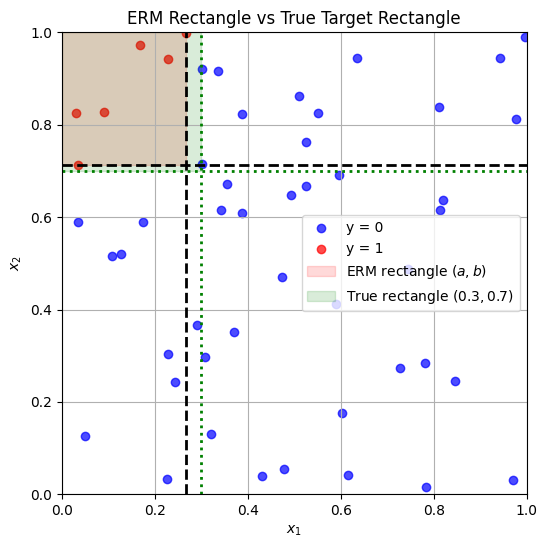

In [67]:
# Task 3 (A) Visualization
y = np.array(y)
plt.figure(figsize=(6, 6))

plt.scatter(X[y==0, 0], X[y==0, 1],color="blue", label="y = 0", alpha=0.7)
plt.scatter(X[y==1, 0], X[y==1, 1],color="red", label="y = 1", alpha=0.7)

plt.axvline(opta, color="black", linestyle="--", linewidth=2)
plt.axhline(optb, color="black", linestyle="--", linewidth=2)
plt.fill_betweenx(
    y=[optb, 1],
    x1=0,
    x2=opta,
    color="red",
    alpha=0.15,
    label="ERM rectangle $(a,b)$"
)

a_true, b_true = 0.3, 0.7
plt.axvline(a_true, color="green", linestyle=":", linewidth=2)
plt.axhline(b_true, color="green", linestyle=":", linewidth=2)
plt.fill_betweenx(
    y=[b_true, 1],
    x1=0,
    x2=a_true,
    color="green",
    alpha=0.15,
    label="True rectangle $(0.3, 0.7)$"
)


plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("ERM Rectangle vs True Target Rectangle")
plt.legend()
plt.grid(True)

plt.show()


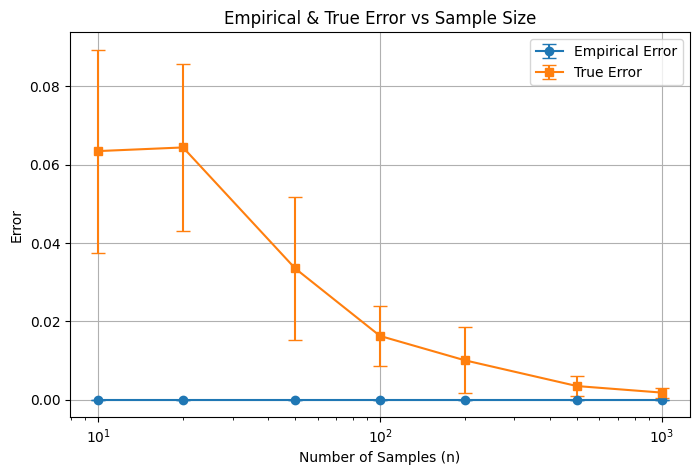

In [68]:
# Task 3 (B)
def true_risk(a, b):
    return a*(1-b) + 0.3*(1-0.7) - 2*(min(a,0.3)*(1-max(b,0.7)))

sample_sizes = [10, 20, 50, 100, 200, 500, 1000]
runs = 20

emp_means, emp_stds = [], []
true_means, true_stds = [], []

# np.random.seed(42)

for n in sample_sizes:
  emp = []
  gen = []

  for _ in range(runs):
    X,y = generate_dataset(n)
    a_hat, b_hat, emp_err = erm_hypothesis_realizable(X,y)
    emp.append(emp_err)
    gen.append(true_risk(a_hat, b_hat))

  emp_means.append(np.mean(emp))
  emp_stds.append(np.std(emp))
  true_means.append(np.mean(gen))
  true_stds.append(np.std(gen))

plt.figure(figsize=(8,5))

plt.errorbar(sample_sizes, emp_means, yerr=emp_stds,
             marker='o', capsize=5, label='Empirical Error')

plt.errorbar(sample_sizes, true_means, yerr=true_stds,
             marker='s', capsize=5, label='True Error')

plt.xscale('log')
plt.xlabel("Number of Samples (n)")
plt.ylabel("Error")
plt.title("Empirical & True Error vs Sample Size")
plt.legend()
plt.grid(True)
plt.show()


In [69]:
# Task 3(C)
N = [50, 100, 200, 300, 500, 800, 1000, 1500]
runs = 50
threshold = 0.05

for n in N:
    success = 0
    for _ in range(runs):
        X, y = generate_dataset(n)
        a_hat, b_hat, _ = erm_hypothesis_realizable(X, y)
        if true_risk(a_hat, b_hat) <= threshold:
            success += 1

    if(success/runs >= 0.95):
        print("Empirical n:", n)
        break

Empirical n: 200


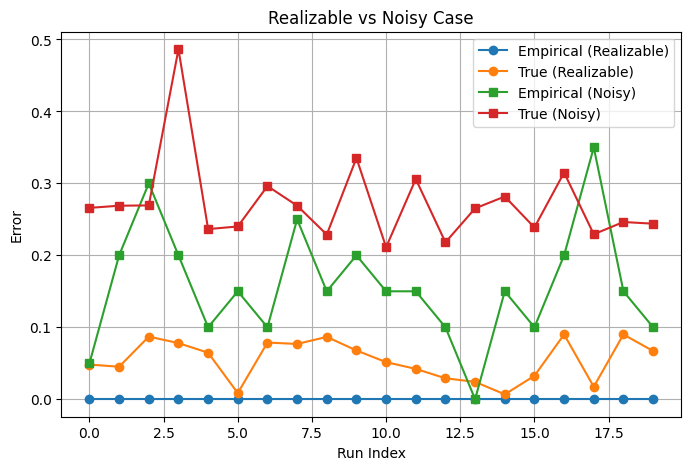

In [70]:
# Task 3(D)
def generate_dataset_noisy(n):
    X = np.random.uniform(0,1,size=(n,2))
    y = []
    for xi in X:
        if(h_star(xi) == 1):
            if(np.random.rand() < 0.8):
              y.append(1)
            else:
              y.append(0)
        else:
            if(np.random.rand() < 0.2):
              y.append(1)
            else:
              y.append(0)
    return X, y

def true_risk_noisy(a,b):
  return 0.2 + 0.6*(a*(1-b) + 0.3*(1-0.7) - 2*(min(a,0.3)*(1-max(b,0.7))))

# Time Complexity exceed for n = 1000
n = 20
runs = 20

empr, truer = [], []
empn, truen = [], []

for _ in range(runs):
  X,y = generate_dataset(n)
  a, b, emp = erm_hypothesis_realizable(X,y)
  empr.append(emp)
  truer.append(true_risk(a, b))

  Xn, yn = generate_dataset_noisy(n)
  an, bn, emp = erm_hypothesis_non_realizable(Xn, yn)
  empn.append(emp)
  truen.append(true_risk_noisy(an, bn))

plt.figure(figsize=(8,5))

plt.plot(empr, label="Empirical (Realizable)", marker='o')
plt.plot(truer, label="True (Realizable)", marker='o')

plt.plot(empn, label="Empirical (Noisy)", marker='s')
plt.plot(truen, label="True (Noisy)", marker='s')

plt.xlabel("Run Index")
plt.ylabel("Error")
plt.title("Realizable vs Noisy Case")
plt.legend()
plt.grid(True)
plt.show()
